Starting Metropolis sampling...
Sampling completed, obtained 9800 effective samples

=== Expected Values ===
E[x]  ≈ 0.017832 (True value: 0)
E[x²] ≈ 0.995531 (True value: 1)
E[x³] ≈ 0.066873 (True value: 0)
E[x⁴] ≈ 2.936682 (True value: 3)


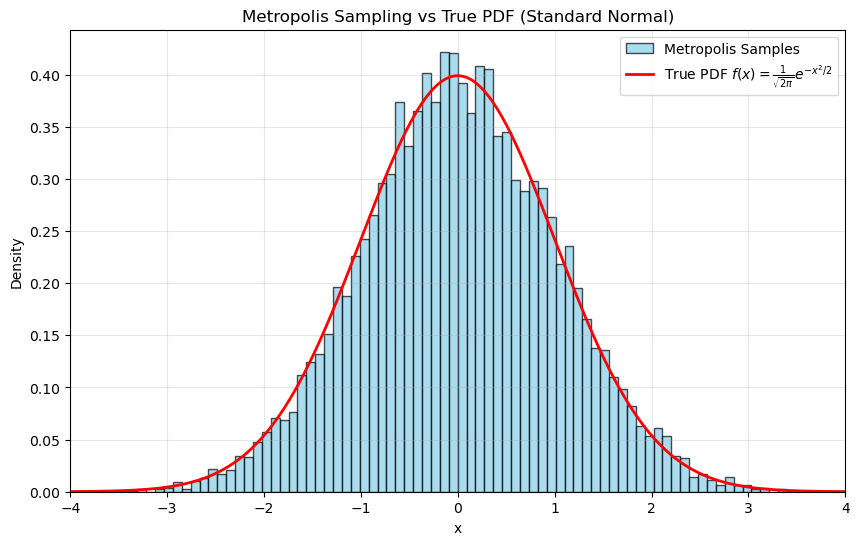

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Target distribution (unnormalized): f(x) ∝ exp(-x²/2)
def target_pdf(x):
    return np.exp(-0.5 * x**2)

def metropolis_sampling(n_steps, proposal_std=1.0, burn_in=1000, thinning=1):
    """
    Sample from f(x) ∝ exp(-x²/2) using Metropolis algorithm
    """
    x = 0.0  # Initial state
    samples = []
    
    for i in range(n_steps):
        # Propose new state: x' = x + noise (symmetric proposal)
        x_proposal = x + np.random.normal(0, proposal_std)
        
        # Calculate acceptance probability: α = min(1, f(x')/f(x))
        acceptance_ratio = target_pdf(x_proposal) / target_pdf(x)
        alpha = min(1.0, acceptance_ratio)
        
        # Accept new state with probability alpha
        if np.random.rand() < alpha:
            x = x_proposal
        
        # Save sample after burn-in and thinning
        if i >= burn_in and i % thinning == 0:
            samples.append(x)
    
    return np.array(samples)

# Main program
n_total_steps = 50000
burn_in = 1000
thinning = 5

print("Starting Metropolis sampling...")
samples = metropolis_sampling(n_total_steps, burn_in=burn_in, thinning=thinning)
print(f"Sampling completed, obtained {len(samples)} effective samples")

# Calculate expected values
mean_x = np.mean(samples)
mean_x2 = np.mean(samples**2)
mean_x3 = np.mean(samples**3)
mean_x4 = np.mean(samples**4)

print("\n=== Expected Values ===")
print(f"E[x]  ≈ {mean_x:.6f} (True value: 0)")
print(f"E[x²] ≈ {mean_x2:.6f} (True value: 1)")
print(f"E[x³] ≈ {mean_x3:.6f} (True value: 0)")
print(f"E[x⁴] ≈ {mean_x4:.6f} (True value: 3)")

# Plotting
x_plot = np.linspace(-4, 4, 500)
pdf_true = np.exp(-0.5 * x_plot**2) / np.sqrt(2 * np.pi)  # Normalized PDF

plt.figure(figsize=(10, 6))

# Plot histogram (density normalized)
plt.hist(samples, bins=80, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Metropolis Samples')

# Plot theoretical PDF
plt.plot(x_plot, pdf_true, 'r-', linewidth=2, label='True PDF $f(x) = \\frac{1}{\\sqrt{2\\pi}} e^{-x^2/2}$')

plt.title('Metropolis Sampling vs True PDF (Standard Normal)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)
plt.show()